In [1]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import astropy
import scipy
import math

## MANUAL TESTING

In [40]:
# IMPORT DATA
data = np.loadtxt("data.dat", skiprows=6)

wl = data[:,0]
flux = data[:,1]
fluxErr = data[:,2]

prior_params = np.array((10, 1000, -50, 0)).reshape(2,2)

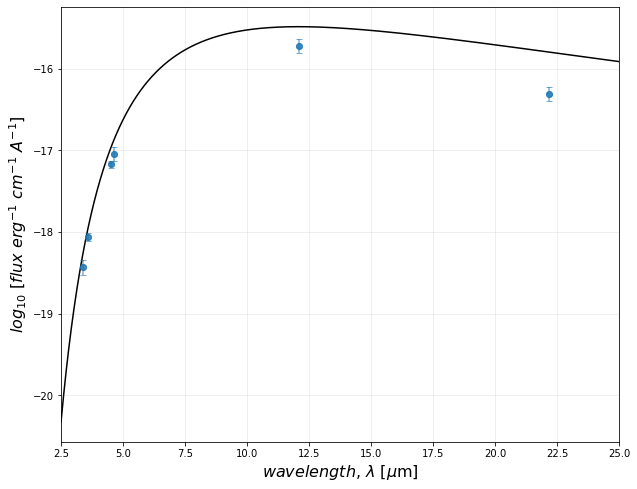

In [249]:
# BRUTE FORCE METHOD and CONSTANT DEFINITION

Teff = 240
a = 22
u = 10**-a
beta = 2*h*u*c**2
alpha = 2*h*c**2
theta = Teff, beta
c = 299792458
h = 6.62607015e-34
kB = 1.380649e-23
conv = 10**-6
b = h*c/(kB*Teff)

# DRAWS A PLANCK DISTRIBUTION ON THESE BOUNDS

left = 2.5
right = 25
x = np.arange(left, right, 0.00001)
result = np.log10(beta) + np.log10(1 / (conv*x)**5 * 1/(np.exp(h*c/(x*conv*kB*Teff))-1))

# COMPUTES THE LOG FLUX FROM WAVELENGTH DATA

for i in range(len(wl)):
    fArr = []
    fNewArr = np.log10(beta) + np.log10(1 / (conv*wl[i])**5 * 1/(np.exp(h*c/(wl[i]*conv*kB*Teff))-1))
    fArr = np.append(fArr, fNewArr)

plt.figure(figsize=(10,8))
plt.plot(x, result, color='k')
plt.scatter(wl, flux, alpha=0.65, zorder=10)
plt.errorbar(wl, flux, yerr=fluxErr, fmt="o", capsize=3, alpha=0.6)
plt.grid(alpha=0.25)
plt.ylabel('$log_{10}$ [$flux$ $erg^{-1}$ $cm^{-1}$ $A^{-1}$]',fontsize=16)
plt.xlabel('$wavelength$, $\lambda$ [$\mu$m]',fontsize=16)
plt.xlim([left, right])

plt.savefig("RawData.png", dpi=300)

## SECTION 1

In [140]:
def model(wl, Teff, logalpha):
    c = 299792458
    h = 6.62607015*10**-34
    kB = 1.380649*10**-23
    logflux = []
    a = 2*h*c**2
    b = h*c/(kB*Teff)
    logflux = []
    for i in range(len(wl)):
        logflux.append(float(np.log10(a) + logalpha + np.log10(1/(np.power(wl[i]*conv,5)*(math.exp(b/(wl[i]*conv))-1)))))
    return logflux

def loglike(wl, flux, fluxErr, theta):
    loglike = 0.0
    for i in range(len(flux)):
        loglike += -(0.5*np.log(2*np.pi))-(np.log(fluxErr[i]))-0.5*(((flux[i]-model(wl, theta[0], theta[1])[i])/fluxErr[i])**2)
    return loglike

def log_prior(theta, thetaspace):
    logprior = np.empty(1)
    #Prior for theta[0]: Teff~logU[Teffmin, Teffmax]
    if theta[0] >= thetaspace[0][0] and theta[0] < thetaspace[0][1]:
        np.append(logprior, np.log(1/(thetaspace[0][1]-thetaspace[0][0])))
    else:
        np.append(logprior, -10e500)

    #Prior for theta[1]: logalpha~U[logalpha_min, logalpha_max]
    if theta[1] >= thetaspace[1][0] and theta[1] < thetaspace[1][1]:
        np.append(logprior, 1/(thetaspace[1][0]-thetaspace[1][1]))
    else:
        np.append(logprior, 1e-500)
    
    return np.sum(logprior)

## SECTIONS 2,3,4,5,6,7

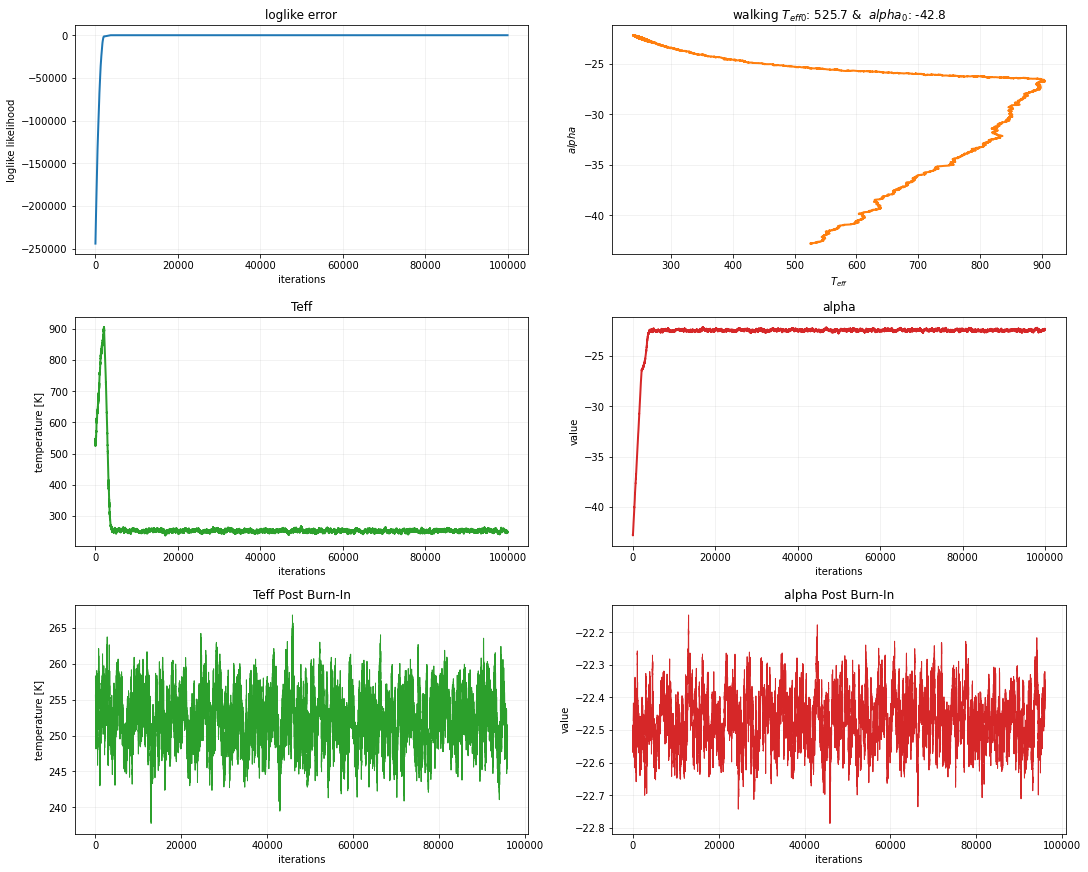

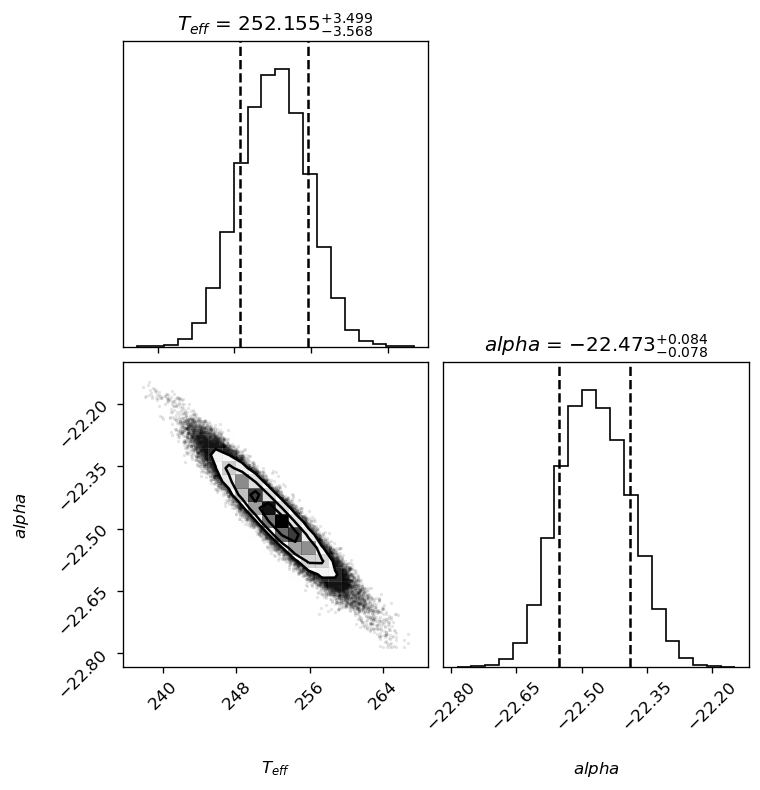

In [235]:
#Initialize the MCMC from a random point drawn from the prior
Teff_0, logalpha_0 = np.random.uniform(10, 1e3, size=None), np.random.uniform(-50, 0, size=None)

#Calculate the associated modified loglike
mod_loglike = loglike(wl, flux, fluxErr, [Teff_0, logalpha_0])
mod_logp = (mod_loglike + log_prior([Teff_0, logalpha_0], prior_params))

# Define proposal jump size:
delta = [1, 0.01]

# Start walking
j=1
jmax=100000
theta_j = [[Teff_0, logalpha_0]]
loglike_j = [mod_loglike]
logp_j = [mod_logp]

while True:
# Generate a proposal with a normal distribution with sigma the previously proposed jump size
    theta_trial=[np.random.normal(theta_j[j-1][0], delta[0]), np.random.normal(theta_j[j-1][1],delta[1])]
    loglike_trial=loglike(wl, flux, fluxErr, theta_trial)
    logp_trial = loglike_trial+log_prior(theta_trial, prior_params)
    
# Compute Metropolis rule
    if j == jmax:
        break
    
    elif loglike_trial > loglike_j[j-1]:
        theta_j.append(theta_trial)
        loglike_j.append(loglike_trial)
        logp_j.append(logp_trial)
        j+=1

    elif loglike_trial <= logp_j[j-1]:
        randomnum = np.random.rand(1)
        if randomnum <= np.exp(-abs(logp_trial-(logp_j[j-1]))):
            theta_j.append(theta_trial)
            loglike_j.append(loglike_trial)
            logp_j.append(logp_trial)
            j+=1
            
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = logp_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if logp_j[i]>median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    
fig, axs = plt.subplots(3, 2, figsize=(15, 12),constrained_layout=True)

axs[0, 0].plot(loglike_j, linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, theta_j_1, 'tab:orange', linewidth=2)
axs[0, 1].set_title('walking $T_{eff0}$: '+ str(round(Teff_0,1)) + ' &  $alpha_{0}$: ' + str(round(logalpha_0,1)))
axs[0, 1].set_xlabel('$T_{eff}$')
axs[0, 1].set_ylabel('$alpha$')

axs[1, 0].plot(theta_j_0, 'tab:green', linewidth=2)
axs[1, 0].set_title('Teff')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('temperature [K]')

axs[1, 1].plot(theta_j_1, 'tab:red', linewidth=2)
axs[1, 1].set_title('alpha')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(theta_j_0[burn:], 'tab:green', linewidth=1)
axs[2, 0].set_title('Teff Post Burn-In')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('temperature [K]')

axs[2, 1].plot(theta_j_1[burn:], 'tab:red', linewidth=1)
axs[2, 1].set_title('alpha Post Burn-In')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')


for ax in axs.flat:
    ax.grid(alpha=0.2)

# CORNER PLOT OF THE Teff AND alpha FROM MCMC

# RESHAPES DATA INTO MULTIDIM ARRAY
TeffArr = np.array(theta_j_0[burn:]).reshape([len(theta_j_0[burn:]),1])
alphaArr = np.array(theta_j_1[burn:]).reshape([len(theta_j_1[burn:]),1])
samples = np.concatenate((TeffArr,alphaArr),axis=1)

fig=plt.figure(figsize=(7,7),dpi=120)
fig=corner.corner(
    samples, labels=[r"$T_{eff}$",r"$alpha$"],quantiles=(0.16, 0.84),show_titles=True,
    title_fmt = '.3f', use_math_text=True, fig=fig)

plt.savefig("CornerPlotsLogUniform.png", dpi=300)

## SECTION 8

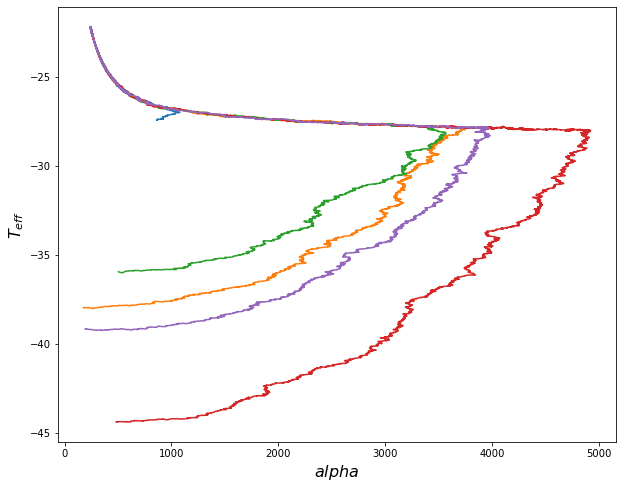

In [260]:
plt.figure(figsize=(10,8))

def run_MCMC(jmax, theta_0, mod_loglike, mod_logp):
    delta = [10, 0.01]
    
    j=1
    theta_j = [theta_0]
    loglike_j = [mod_loglike]
    logp_j = [mod_logp]

    while True:
        #Generate a proposal
        theta_trial=[np.random.normal(theta_j[j-1][0], delta[0]), np.random.normal(theta_j[j-1][1],delta[1])]
        loglike_trial=loglike(wl, flux, fluxErr, theta_trial)
        logp_trial = loglike_trial+log_prior(theta_trial, prior_params)

        #Compute Metropolis rule
        if j == jmax:
            break
        elif loglike_trial > loglike_j[j-1]:
            theta_j.append(theta_trial)
            loglike_j.append(loglike_trial)
            logp_j.append(logp_trial)
            j+=1

        elif loglike_trial <= logp_j[j-1]:
            randomnum = np.random.rand(1)
            if randomnum <= np.exp(-abs(logp_trial-(logp_j[j-1]))):
                theta_j.append(theta_trial)
                loglike_j.append(loglike_trial)
                logp_j.append(logp_trial)
                j+=1
                
    theta_j_0 = []
    theta_j_1 = []

    for i in theta_j:
        theta_j_0.append(i[0])
        theta_j_1.append(i[1])

    
    plt.ylabel('$T_{eff}$',fontsize=16)
    plt.xlabel('$alpha$',fontsize=16)
    return plt.plot(theta_j_0, theta_j_1)

i = 0
while i < 5:
    #Initialize the MCMC from a random point drawn from the prior
    Teff_0, logalpha_0 = np.random.uniform(10, 1000, size=None), np.random.uniform(-50, 0, size=None)

    #Calculate the associated modified loglike
    mod_loglike = loglike(wl,flux,fluxErr, [Teff_0, logalpha_0])
    mod_logp = (mod_loglike + log_prior([Teff_0, logalpha_0], prior_params))

    run_MCMC(10000, [Teff_0, logalpha_0], mod_loglike, mod_logp)
    plt.savefig("WalkerMultiple" + str(i) + ".png", dpi=300)
    i+=1

## SECTION 9 UNIFORM

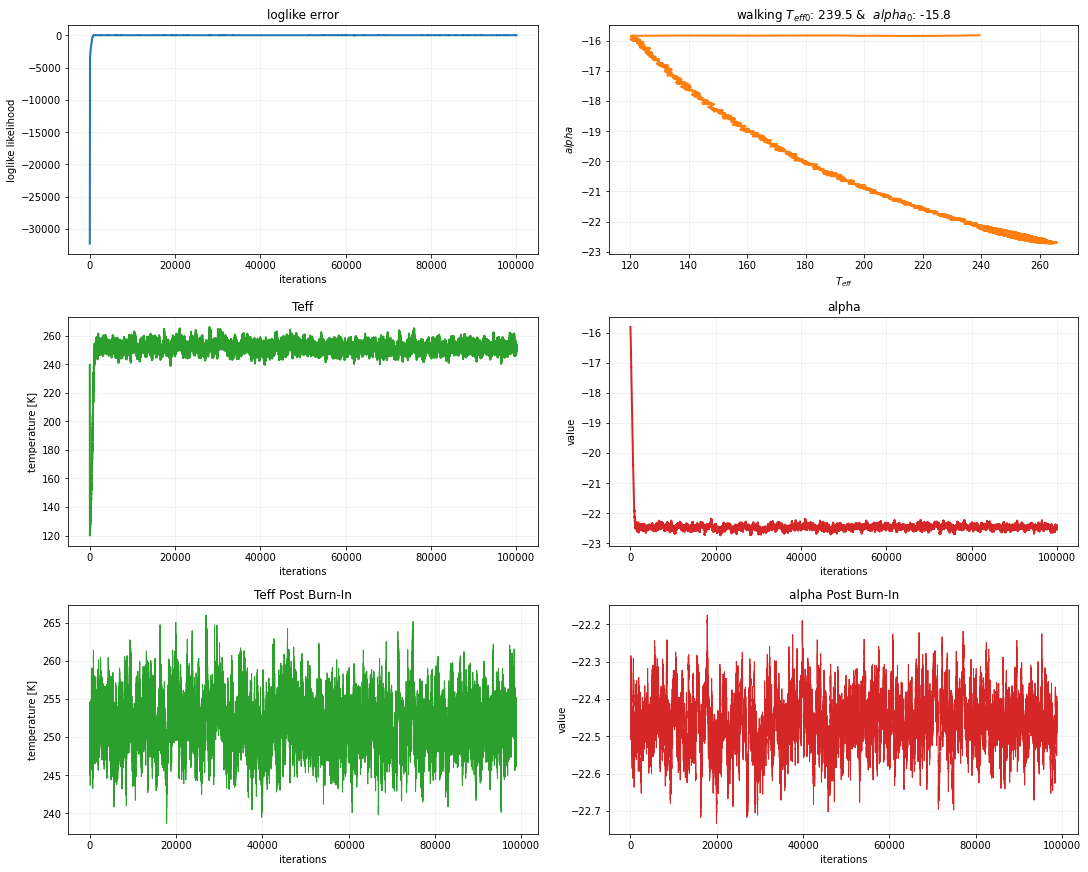

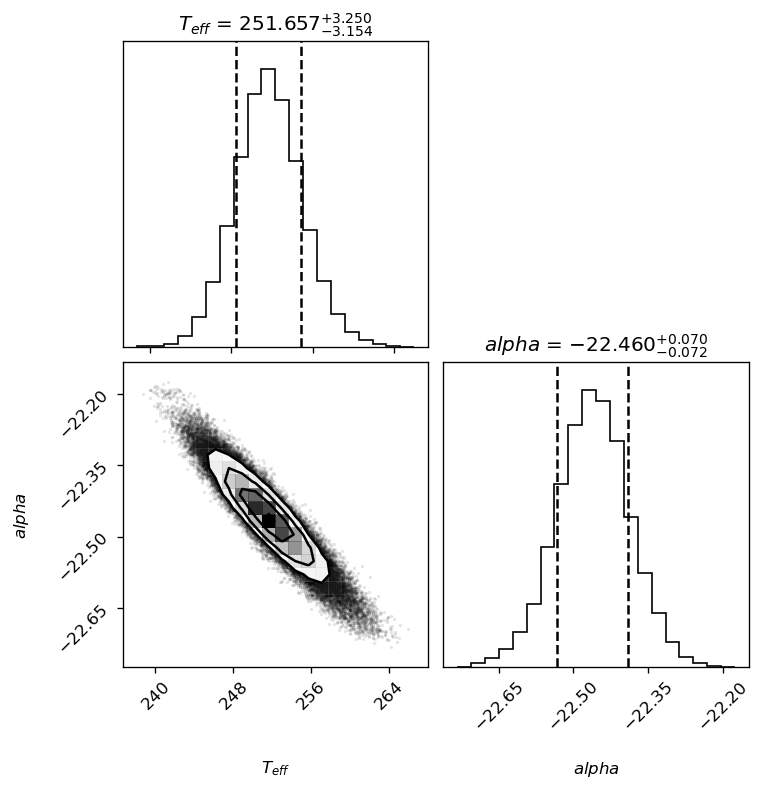

In [261]:
#Defining a Uniform T prior 
def log_prior(theta, thetaspace):
    logprior = np.empty(1)
    #Prior for theta[0]: Teff~U[Teffmin, Teffmax]
    if theta[0] >= thetaspace[0][0] and theta[0] < thetaspace[0][1]:
        np.append(logprior, 1/(thetaspace[0][1]-thetaspace[0][0]))
    else:
        np.append(logprior, 1e-1000)

    #Prior for theta[1]: logalpha~U[logalpha_min, logalpha_max]
    if theta[1] >= thetaspace[1][0] and theta[1] < thetaspace[1][1]:
        np.append(logprior, 1/(thetaspace[1][0]-thetaspace[1][1]))
    else:
        np.append(logprior, 1e-500)
    
    return np.sum(logprior)

#Initialize the MCMC from a random point drawn from the prior
Teff_0, logalpha_0 = np.random.uniform(10, 1000, size=None), np.random.uniform(-50, 0, size=None)

#Calculate the associated modified loglike
mod_loglike = loglike(wl, flux, fluxErr, [Teff_0, logalpha_0])
mod_logp = (mod_loglike + log_prior([Teff_0, logalpha_0], prior_params))

# Define proposal jump size:
delta = [10, 0.01]

# Start walking
j=1
jmax=100000
theta_j = [[Teff_0, logalpha_0]]
loglike_j = [mod_loglike]
logp_j = [mod_logp]

while True:
    #Generate a proposal
    theta_trial=[np.random.normal(theta_j[j-1][0], delta[0]), np.random.normal(theta_j[j-1][1],delta[1])]
    loglike_trial=loglike(wl, flux, fluxErr, theta_trial)
    logp_trial = loglike_trial+log_prior(theta_trial, prior_params)

    #Compute Metropolis rule
    if j == jmax:
        break
    elif loglike_trial > loglike_j[j-1]:
        theta_j.append(theta_trial)
        loglike_j.append(loglike_trial)
        logp_j.append(logp_trial)
        j+=1
    
    elif loglike_trial <= logp_j[j-1]:
        randomnum = np.random.rand(1)
        if randomnum <= np.exp(-abs(logp_trial-(logp_j[j-1]))):
            theta_j.append(theta_trial)
            loglike_j.append(loglike_trial)
            logp_j.append(logp_trial)
            j+=1
    
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = logp_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if logp_j[i]>median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    
fig, axs = plt.subplots(3, 2, figsize=(15, 12),constrained_layout=True)

axs[0, 0].plot(loglike_j, linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, theta_j_1, 'tab:orange', linewidth=2)
axs[0, 1].set_title('walking $T_{eff0}$: '+ str(round(Teff_0,1)) + ' &  $alpha_{0}$: ' + str(round(logalpha_0,1)))
axs[0, 1].set_xlabel('$T_{eff}$')
axs[0, 1].set_ylabel('$alpha$')

axs[1, 0].plot(theta_j_0, 'tab:green', linewidth=2)
axs[1, 0].set_title('Teff')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('temperature [K]')

axs[1, 1].plot(theta_j_1, 'tab:red', linewidth=2)
axs[1, 1].set_title('alpha')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(theta_j_0[burn:], 'tab:green', linewidth=1)
axs[2, 0].set_title('Teff Post Burn-In')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('temperature [K]')

axs[2, 1].plot(theta_j_1[burn:], 'tab:red', linewidth=1)
axs[2, 1].set_title('alpha Post Burn-In')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# CORNER PLOT OF THE Teff AND alpha FROM MCMC

# RESHAPES DATA INTO MULTIDIM ARRAY
TeffArr = np.array(theta_j_0[burn:]).reshape([len(theta_j_0[burn:]),1])
alphaArr = np.array(theta_j_1[burn:]).reshape([len(theta_j_1[burn:]),1])
samples = np.concatenate((TeffArr,alphaArr),axis=1)

fig=plt.figure(figsize=(7,7),dpi=120)
fig=corner.corner(
    samples, labels=[r"$T_{eff}$",r"$alpha$"],quantiles=(0.16, 0.84),show_titles=True,
    title_fmt = '.3f', use_math_text=True, fig=fig)

plt.savefig("CornerPlotsUniform.png", dpi=300)

## SECTION 9 UNIFORM T^4

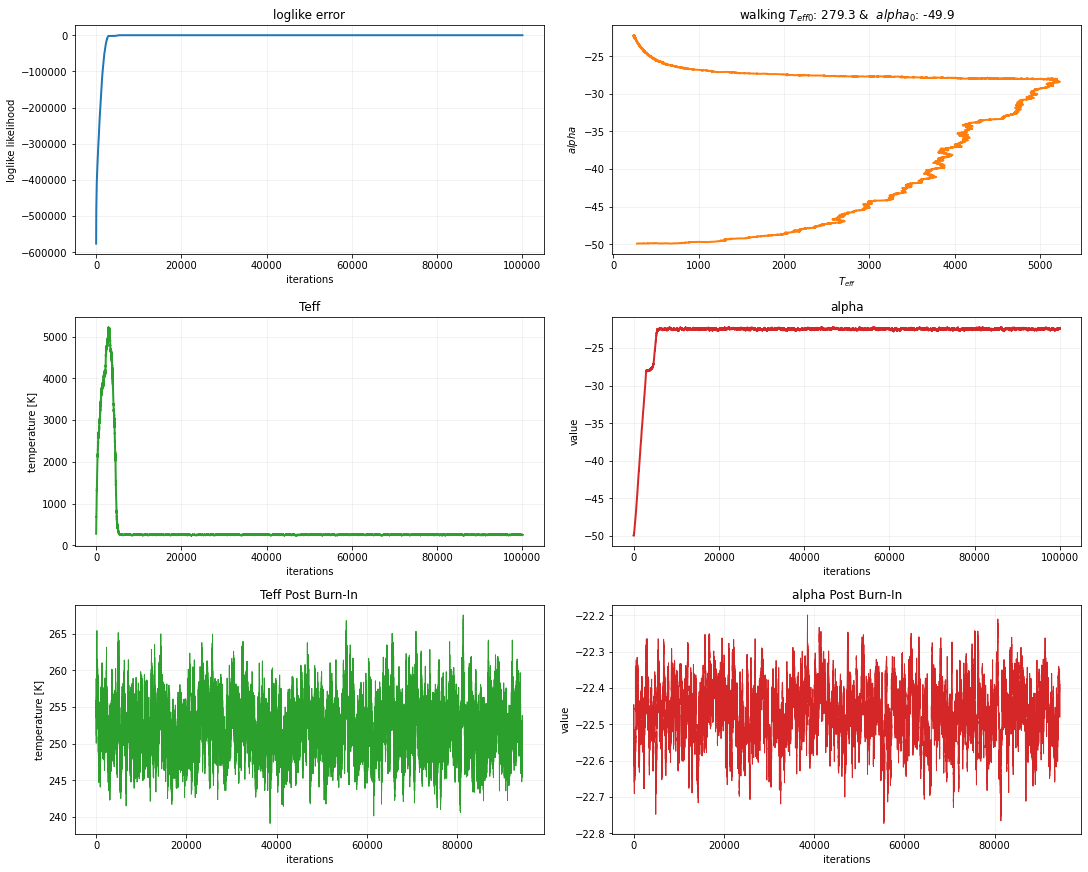

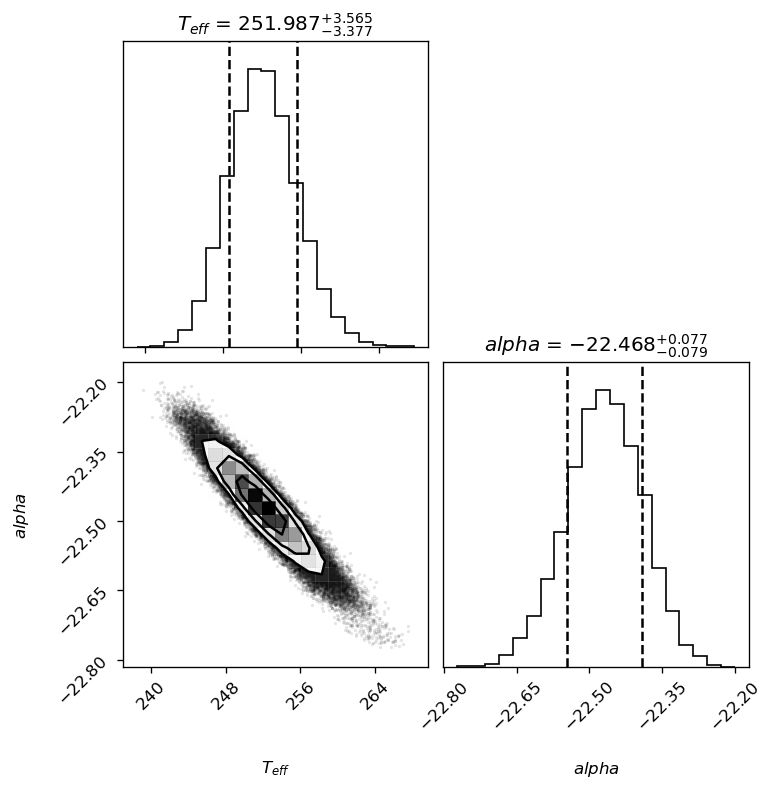

In [263]:
#Defining a Uniform in T^4 prior 
def log_prior(theta, thetaspace):
    logprior = np.empty(1)
    #Prior for theta[0]: Teff~U[Teffmin^4, Teffmax^4]
    if theta[0] >= thetaspace[0][0] and theta[0] < thetaspace[0][1]:
        np.append(logprior, 1/(thetaspace[0][1]**4-thetaspace[0][0]**4))
    else:
        np.append(logprior, 1e-1000000)

    #Prior for theta[1]: logalpha~U[logalpha_min, logalpha_max]
    if theta[1] >= thetaspace[1][0] and theta[1] < thetaspace[1][1]:
        np.append(logprior, 1/(thetaspace[1][0]-thetaspace[1][1]))
    else:
        np.append(logprior, 1e-1000000)
    
    return np.sum(logprior)

#Initialize the MCMC from a random point drawn from the prior
Teff_0, logalpha_0 = np.random.uniform(10, 1000, size=None), np.random.uniform(-50, 0, size=None)

#Calculate the associated modified loglike
mod_loglike = loglike(wl, flux, fluxErr, [Teff_0, logalpha_0])
mod_logp = (mod_loglike + log_prior([Teff_0, logalpha_0], prior_params))
mod_loglike, mod_logp, Teff_0, logalpha_0

# Define proposal jump size:
delta = [10, 0.01]

# Start walking
j=1
jmax=100000
theta_j = [[Teff_0, logalpha_0]]
loglike_j = [mod_loglike]
logp_j = [mod_logp]

while True:
    #Generate a proposal
    theta_trial=[np.random.normal(theta_j[j-1][0], delta[0]), np.random.normal(theta_j[j-1][1],delta[1])]
    loglike_trial=loglike(wl, flux, fluxErr, theta_trial)
    logp_trial = loglike_trial+log_prior(theta_trial, prior_params)

    #Compute Metropolis rule
    if j == jmax:
        break
    elif loglike_trial > loglike_j[j-1]:
        theta_j.append(theta_trial)
        loglike_j.append(loglike_trial)
        logp_j.append(logp_trial)
        j+=1
    
    elif loglike_trial <= logp_j[j-1]:
        randomnum = np.random.rand(1)
        if randomnum <= np.exp(-abs(logp_trial-(logp_j[j-1]))):
            theta_j.append(theta_trial)
            loglike_j.append(loglike_trial)
            logp_j.append(logp_trial)
            j+=1
            
#Use the median to define burn-in. That is, compute the median of log probabilities,
ordered_list = logp_j.copy()
ordered_list.sort()
mid = len(ordered_list) // 2
median = (ordered_list[mid] + ordered_list[~mid]) / 2

for i in range(len(logp_j)):
    if logp_j[i]>median:
        burn = i
        break
        
theta_j_0 = []
theta_j_1 = []

for i in theta_j:
    theta_j_0.append(i[0])
    theta_j_1.append(i[1])
    
fig, axs = plt.subplots(3, 2, figsize=(15, 12),constrained_layout=True)

axs[0, 0].plot(loglike_j, linewidth=2)
axs[0, 0].set_title('loglike error')
axs[0, 0].set_xlabel('iterations')
axs[0, 0].set_ylabel('loglike likelihood')

axs[0, 1].plot(theta_j_0, theta_j_1, 'tab:orange', linewidth=2)
axs[0, 1].set_title('walking $T_{eff0}$: '+ str(round(Teff_0,1)) + ' &  $alpha_{0}$: ' + str(round(logalpha_0,1)))
axs[0, 1].set_xlabel('$T_{eff}$')
axs[0, 1].set_ylabel('$alpha$')

axs[1, 0].plot(theta_j_0, 'tab:green', linewidth=2)
axs[1, 0].set_title('Teff')
axs[1, 0].set_xlabel('iterations')
axs[1, 0].set_ylabel('temperature [K]')

axs[1, 1].plot(theta_j_1, 'tab:red', linewidth=2)
axs[1, 1].set_title('alpha')
axs[1, 1].set_xlabel('iterations')
axs[1, 1].set_ylabel('value')

axs[2, 0].plot(theta_j_0[burn:], 'tab:green', linewidth=1)
axs[2, 0].set_title('Teff Post Burn-In')
axs[2, 0].set_xlabel('iterations')
axs[2, 0].set_ylabel('temperature [K]')

axs[2, 1].plot(theta_j_1[burn:], 'tab:red', linewidth=1)
axs[2, 1].set_title('alpha Post Burn-In')
axs[2, 1].set_xlabel('iterations')
axs[2, 1].set_ylabel('value')

for ax in axs.flat:
    ax.grid(alpha=0.2)

# CORNER PLOT OF THE Teff AND alpha FROM MCMC

# RESHAPES DATA INTO MULTIDIM ARRAY
TeffArr = np.array(theta_j_0[burn:]).reshape([len(theta_j_0[burn:]),1])
alphaArr = np.array(theta_j_1[burn:]).reshape([len(theta_j_1[burn:]),1])
samples = np.concatenate((TeffArr,alphaArr),axis=1)

fig=plt.figure(figsize=(7,7),dpi=120)
fig=corner.corner(
    samples, labels=[r"$T_{eff}$",r"$alpha$"],quantiles=(0.16, 0.84),show_titles=True,
    title_fmt = '.3f', use_math_text=True, fig=fig)

plt.savefig("CornerPlotsUniformT4.png", dpi=300)